In [4]:
import SimpleITK as sitk
import numpy as np
import os
import matplotlib.pyplot as plt

# resmaple the US image to isotropic spacing of 0.5mm x 0.5mm x 0.5mm

def resample_us_image(us_image_path, new_spacing):
    # read the image
    us_image = sitk.ReadImage(us_image_path)
    print('US Image Size:', us_image.GetSize())
    print('US Image Spacing:', us_image.GetSpacing())
    print('US Image Origin:', us_image.GetOrigin())
    print('US Image Direction:', us_image.GetDirection())

    #I want to resample the image to have isotropic spacing of 0.5mm x 0.5mm x 0.5mm
    new_spacing = [new_spacing[0], new_spacing[1], new_spacing[2]]
    original_size = us_image.GetSize()
    original_spacing = us_image.GetSpacing()
    new_size = [int(round(original_size[i] * (original_spacing[i] / new_spacing[i]))) for i in range(3)]
    resample = sitk.ResampleImageFilter()
    resample.SetOutputSpacing(new_spacing)
    resample.SetSize(new_size)
    resample.SetOutputDirection(us_image.GetDirection())
    resample.SetOutputOrigin(us_image.GetOrigin())

    resample.SetInterpolator(sitk.sitkLinear)
    resampled_image = resample.Execute(us_image)
    print('Resampled Image Size:', resampled_image.GetSize())
    print('Resampled Image Spacing:', resampled_image.GetSpacing())
    print('Resampled Image Origin:', resampled_image.GetOrigin())
    print('Resampled Image Direction:', resampled_image.GetDirection())
    #save the resampled image
    #sitk.WriteImage(resampled_image, output_path)
    return resampled_image

#write image slice to png function
"""skip_indx: int, 
slice_direction: 0, 1, 2 axial, sagittal, coronal, 
output_path: str
"""
def slice_to_png(image, skip_index, output_path):
    """
    每隔 skip_index 张切一张, 分别沿3个方向保存 (axial, sagittal, coronal)
    参数:
        image: SimpleITK.Image 或 .nii/.nii.gz 路径
        skip_index: int, 表示间隔 (e.g., 2 表示 0,2,4,6,...)
        output_path: 保存文件夹路径
    """
    # ---- 1. 如果传的是路径，先读入 SimpleITK 图像 ----
    if isinstance(image, str):
        image = sitk.ReadImage(image)
        print(f"Loaded image from: {image}")

    # ---- 2. 创建三个方向文件夹 ----
    dirs = {
        'axial':    os.path.join(output_path, 'axial'),
        'sagittal': os.path.join(output_path, 'sagittal'),
        'coronal':  os.path.join(output_path, 'coronal')
    }
    for d in dirs.values():
        os.makedirs(d, exist_ok=True)

    size = image.GetSize()  # (x, y, z)
    print(f"Image size (x, y, z): {size}")
    print(f"Skip step = {skip_index}")

    # ---- 3. 定义三个方向的切片与保存逻辑 ----

    # --- Axial (Z 方向) ---
    for i in range(0, size[2], skip_index):
        arr = sitk.GetArrayFromImage(image[:, :, i])
        #arr = normalize_slice(arr)
        #plt.imsave(os.path.join(dirs['axial'], f"slice_{i:03d}.png"), arr, cmap='gray')

    # --- Sagittal (X 方向) ---
    for i in range(0, size[0], skip_index):
        arr = sitk.GetArrayFromImage(image[i, :, :])
        #arr = normalize_slice(arr)
        #plt.imsave(os.path.join(dirs['sagittal'], f"slice_{i:03d}.png"), arr, cmap='gray')

    # --- Coronal (Y 方向) ---
    for i in range(0, size[1], skip_index):
        arr = sitk.GetArrayFromImage(image[:, i, :])
        #arr = normalize_slice(arr)
        #plt.imsave(os.path.join(dirs['coronal'], f"slice_{i:03d}.png"), arr, cmap='gray')

    print(f"✅ Slices saved to: {output_path}")



    
    



In [ ]:
import matplotlib.pyplot as plt
import numpy as np

image_path='G:\\Dino3Registration\\data\\orginal_data\\Case6\\MRI\\Case6-T1.nii.gz'

resample_image_array=resample_us_image(image_path,[0.5,0.5,0.5])
print("resample_image_array size:",resample_image_array.GetSize())
# resamle to [224,192,224]
# resample_us_image_array = resample_us_image_array.astype(np.float32)
# resample_us_image_array = (resample_us_image_array - resample_us_image_array.min()) / (resample_us_image_array.max() - resample_us_image_array.min() + 1e-8)
# resample_us_image_array = (resample_us_image_array * 255).astype(np.uint8)

slice_to_png(resample_image_array,2,"G:\\Dino3Registration\\data\\sliced_png\\Case6\\MRI")






US Image Size: (192, 256, 256)
US Image Spacing: (1.0, 1.0, 1.0)
US Image Origin: (95.12328338623047, 128.9263916015625, -178.67062377929688)
US Image Direction: (-0.9998964952548128, 0.003493001145974097, 0.013956995530026823, -0.0034926593149307242, -0.9999938994528811, 4.887602646610684e-05, 0.013957080928748195, 1.2393891520834897e-07, 0.9999025951996068)
Resampled Image Size: (384, 512, 512)
Resampled Image Spacing: (0.5, 0.5, 0.5)
Resampled Image Origin: (95.12328338623047, 128.9263916015625, -178.67062377929688)
Resampled Image Direction: (-0.9998964952548128, 0.003493001145974097, 0.013956995530026823, -0.0034926593149307242, -0.9999938994528811, 4.887602646610684e-05, 0.013957080928748195, 1.2393891520834897e-07, 0.9999025951996068)
resample_image_array size: (384, 512, 512)
Image size (x, y, z): (384, 512, 512)
Skip step = 2
✅ Slices saved to: G:\Dino3Registration\data\sliced_png\Case6\MRI


File: G:\Dino3Registration\data_pre\US_image_resampled_Bspline.jpeg
Shape (H, W): (369, 231)
Data type: float32
Min intensity: 3.0
Max intensity: 241.0
Mean intensity: 53.744728
Std intensity: 33.69353
Non-zero pixel ratio: 1.0


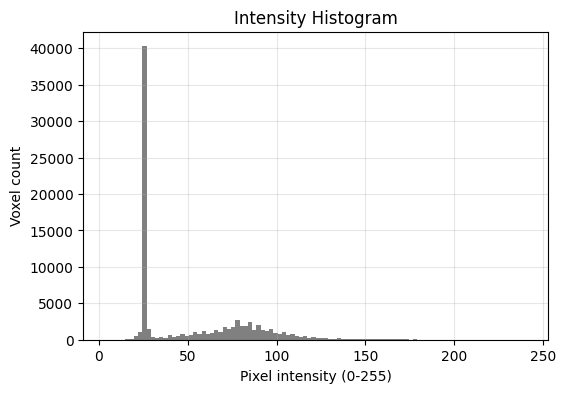

In [59]:
#check png image intensity



import numpy as np
from PIL import Image, ImageOps
import matplotlib.pyplot as plt

# === 修改为你的 PNG 路径 ===
png_path = r"G:\Dino3Registration\data_pre\US_image_resampled_Bspline.jpeg"
#png_path=r"G:\\Dino3Registration\\test_feature\\US_image\\Case1-US-before.jpeg"
# 1) 读取 PNG 图像并确保方向正确
img = Image.open(png_path)
img = ImageOps.exif_transpose(img)   # 修正 EXIF 旋转

# 2) 转为灰度（即单通道）
if img.mode != "L":
    img_gray = img.convert("L")
else:
    img_gray = img

# 3) 转 numpy array
arr = np.array(img_gray).astype(np.float32)

# 4) 打印统计信息
print(f"File: {png_path}")
print("Shape (H, W):", arr.shape)
print("Data type:", arr.dtype)
print("Min intensity:", np.min(arr))
print("Max intensity:", np.max(arr))
print("Mean intensity:", np.mean(arr))
print("Std intensity:", np.std(arr))
print("Non-zero pixel ratio:", np.count_nonzero(arr) / arr.size)

# 5) 绘制强度分布直方图
plt.figure(figsize=(6,4))
plt.hist(arr.flatten(), bins=100, color='gray')
plt.title("Intensity Histogram")
plt.xlabel("Pixel intensity (0-255)")
plt.ylabel("Voxel count")
plt.grid(alpha=0.3)
plt.show()



File: G:\\Dino3Registration\\data_pre\\US_image_resampled.jpeg
Shape (H, W): (369, 231)
Data type: float32
Min intensity: 0.0
Max intensity: 242.0
Mean intensity: 32.353218
Std intensity: 38.669872
Non-zero pixel ratio: 0.513802367460904


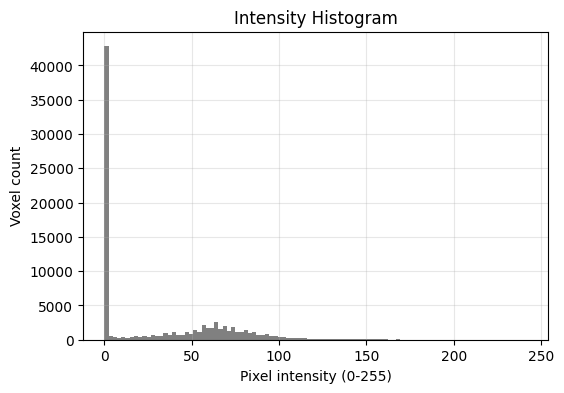

In [58]:
png_path = r"G:\\Dino3Registration\\data_pre\\US_image_resampled.jpeg"
#png_path=r"G:\\Dino3Registration\\test_feature\\US_image\\Case1-US-before.jpeg"
# 1) 读取 PNG 图像并确保方向正确
img = Image.open(png_path)
img = ImageOps.exif_transpose(img)   # 修正 EXIF 旋转

# 2) 转为灰度（即单通道）
if img.mode != "L":
    img_gray = img.convert("L")
else:
    img_gray = img

# 3) 转 numpy array
arr = np.array(img_gray).astype(np.float32)

# 4) 打印统计信息
print(f"File: {png_path}")
print("Shape (H, W):", arr.shape)
print("Data type:", arr.dtype)
print("Min intensity:", np.min(arr))
print("Max intensity:", np.max(arr))
print("Mean intensity:", np.mean(arr))
print("Std intensity:", np.std(arr))
print("Non-zero pixel ratio:", np.count_nonzero(arr) / arr.size)

# 5) 绘制强度分布直方图
plt.figure(figsize=(6,4))
plt.hist(arr.flatten(), bins=100, color='gray')
plt.title("Intensity Histogram")
plt.xlabel("Pixel intensity (0-255)")
plt.ylabel("Voxel count")
plt.grid(alpha=0.3)
plt.show()


In [1]:
from transformers import pipeline
from transformers.image_utils import load_image

url = "G:\\Dino3Registration\\data\\sliced_png\\Case6\\MRI\\coronal\\slice_224.png"
image = load_image(url)
#print image size
print(f"[info] image size: {image.size}")
feature_extractor = pipeline(
    model="facebook/dinov3-vitl16-pretrain-lvd1689m",
    task="image-feature-extraction", 
)
features = feature_extractor(image)
import numpy as np
# Convert features to numpy array and print its shape
features_np = np.array(features)
print(features_np.shape)

#save the features to a npy file
np.save("G:\\Dino3Registration\\test_feature\\encoderTest\\pipelen_encoder_features_case6_mri_slice224.npy", features_np)

c:\Users\Ruoya\anaconda3\envs\dino3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[info] image size: (384, 512)


Fetching 1 files: 100%|██████████| 1/1 [00:00<?, ?it/s]
Device set to use cpu


(1, 201, 1024)


In [ ]:
#wirte a code to patch the image by 16

In [7]:
# fixed the image spacing and only change the image size

MODEL_NAME = "facebook/dinov3-vitl16-pretrain-lvd1689m"   # ViT-L/16 变体


SAVE_PATH  = "G:\\Dino3Registration\\test_feature\\dino3\\"+MODEL_NAME.split("/")[-1]+"_featurecheck.png"
print("SAVE_PATH:",SAVE_PATH)

SAVE_PATH: G:\Dino3Registration\test_feature\dino3\dinov3-vitl16-pretrain-lvd1689m_featurecheck.png


新 size: (1024, 1024)
原图 spacing: (1.0, 1.0)
原图 size: (192, 256)
重采样后 spacing: (0.1875, 0.25)
重采样后 size: (1024, 1024)


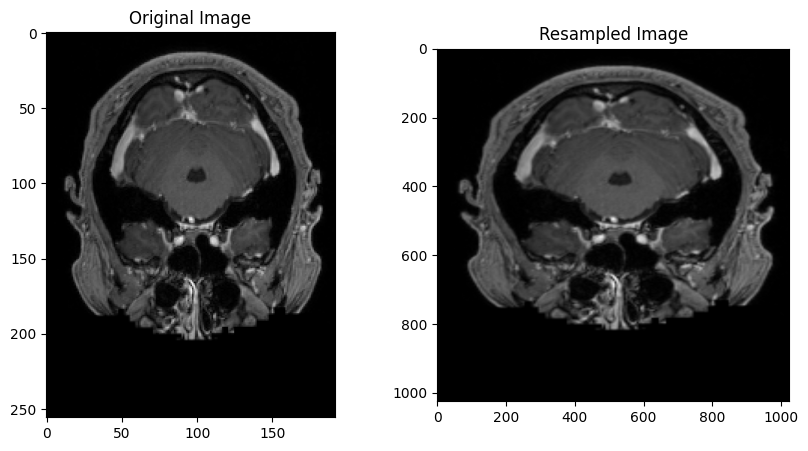

In [ ]:
import SimpleITK as sitk
import matplotlib.pyplot as plt
import numpy as np
image_path='G:\\Dino3Registration\\data\\orginal_data\\Case6\\MRI\\Case6-T1.nii.gz'
#get the middle slice of the image
middle_slice_index=112
img=sitk.ReadImage(image_path)[:,:,middle_slice_index]


# old_size, old_spacing
N = np.array(img.GetSize(), dtype=np.float64)[:2]
s = np.array(img.GetSpacing(), dtype=np.float64)[:2]
N_tgt = np.array([1024, 1024], dtype=np.float64)

# 关键公式：保持 FOV 不变
s_tgt = s * (N / N_tgt)

ref = sitk.Image(int(N_tgt[0]), int(N_tgt[1]), img.GetPixelID())
ref.SetSpacing(tuple(s_tgt.tolist()))
ref.SetOrigin(img.GetOrigin())
ref.SetDirection(img.GetDirection())

out = sitk.Resample(img, ref, sitk.Transform(),
                          sitk.sitkLinear, 0.0, img.GetPixelID())

print("新 size:", out.GetSize())   

#plot both image and see
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(sitk.GetArrayFromImage(img), cmap='gray')
axs[0].set_title('Original Image')
axs[1].imshow(sitk.GetArrayFromImage(out), cmap='gray')
axs[1].set_title('Resampled Image')

print("原图 spacing:", img.GetSpacing())
print("原图 size:", img.GetSize())
print("重采样后 spacing:", out.GetSpacing())
print("重采样后 size:", out.GetSize())

#save the resampled image
SAVE_PATH = 'G:\\Dino3Registration\\data\\reshape_size\\Case6-T1_resampled.nii.gz'



In [1]:
import SimpleITK as sitk
import numpy as np

def compute_target_spacing(feature_spacing: float,
                           patch_size: int) -> float:
    """
    根据 feature spacing 与 DINO patch size 计算所需重采样 spacing。
    require_spacing = feature_spacing / patch_size
    例如 feature_spacing=2, patch_size=16 → 0.125
    """
    return feature_spacing / patch_size


def resample_to_target(itk_img: sitk.Image,
                       feature_spacing: float = 2.0,
                       patch_size: int = 16,
                       interp: str = 'linear') -> sitk.Image:
    """
    自动根据 DINO feature spacing 与 patch size 计算目标 spacing，
    然后重采样 3D 图像。
    """
    # 计算目标 spacing
    target_spacing = compute_target_spacing(feature_spacing, patch_size)
    target_spacing = (target_spacing,) * 3  # 各方向相同

    orig_spacing = np.array(itk_img.GetSpacing(), dtype=float)
    orig_size = np.array(itk_img.GetSize(), dtype=int)
    new_size = np.round(orig_size * (orig_spacing / target_spacing)).astype(int).tolist()

    print(f"Original spacing: {orig_spacing}, size: {orig_size}")
    print(f"Target spacing  : {target_spacing}, new size: {new_size}")

    # 选择插值器
    interpolator = sitk.sitkLinear if interp == 'linear' else sitk.sitkNearestNeighbor

    resampler = sitk.ResampleImageFilter()
    resampler.SetOutputSpacing(target_spacing)
    resampler.SetSize(new_size)
    resampler.SetOutputDirection(itk_img.GetDirection())
    resampler.SetOutputOrigin(itk_img.GetOrigin())
    resampler.SetTransform(sitk.Transform())
    resampler.SetInterpolator(interpolator)

    return resampler.Execute(itk_img)





In [2]:
# ================== 示例 ==================
# MRI: (107,96,114) spacing=(1,1,1)
image_path='G:\\Dino3Registration\\data\\orginal_data\\Case6\\MRI\\Case6-T1.nii.gz'
mri = sitk.ReadImage(image_path)


# 
mri_resampled = resample_to_target(mri, feature_spacing=3.0, patch_size=16)

# 输出:
# Original spacing: [1. 1. 1.], size: [107  96 114]
# Target spacing  : (0.125, 0.125, 0.125), new size: [856 768 912]
#save the image
sitk.WriteImage(mri_resampled, 'G:\\Dino3Registration\\data\\reshape_size\\Case6-T1_dino_resampled_spacing3.nii.gz')

Original spacing: [1. 1. 1.], size: [192 256 256]
Target spacing  : (0.1875, 0.1875, 0.1875), new size: [1024, 1365, 1365]


In [2]:
import cv2
import numpy as np
import SimpleITK as sitk

def compute_target_spacing(feature_spacing: float,
                           patch_size: int) -> float:
    """
    根据 DINO 的 feature spacing 与 patch size 计算目标 spacing。
    require_spacing = feature_spacing / patch_size
    例如 feature_spacing=2, patch_size=16 → 0.125
    """
    return feature_spacing / patch_size


def resample_png_to_target(png_path: str,
                           orig_spacing: tuple = (1.0, 1.0),
                           feature_spacing: float = 2.0,
                           patch_size: int = 16,
                           interp: str = 'linear',
                           save_path: str = None):
    """
    对 2D PNG 图像进行重采样（仅 XY），根据 feature_spacing / patch_size 自动计算目标 spacing。
    - png_path: 原始 PNG 路径
    - orig_spacing: 原始像素 spacing（单位 mm/px）
    - feature_spacing: DINO feature map spacing
    - patch_size: DINO patch size（通常 16）
    - interp: 'linear' 或 'nearest'
    - save_path: 保存路径（可选）
    """

    # 计算目标 spacing
    target_spacing = compute_target_spacing(feature_spacing, patch_size)
    target_spacing_xy = (target_spacing, target_spacing)

    # 读取 PNG
    img = cv2.imread(png_path, cv2.IMREAD_UNCHANGED)
    if img is None:
        raise FileNotFoundError(png_path)

    # 若为灰度，转成单通道
    if img.ndim == 2:
        img = img[..., np.newaxis]

    # 原尺寸与 spacing
    h, w = img.shape[:2]
    ox, oy = orig_spacing

    # 计算新尺寸 = round(orig_size * (orig_spacing / target_spacing))
    new_w = int(round(w * (ox / target_spacing_xy[0])))
    new_h = int(round(h * (oy / target_spacing_xy[1])))

    # 插值选择
    if interp == 'nearest':
        cv_interp = cv2.INTER_NEAREST
    else:
        cv_interp = cv2.INTER_LINEAR

    # 重采样
    img_resampled = cv2.resize(img, (new_w, new_h), interpolation=cv_interp)

    # 输出信息
    print(f"Original size: {(w,h)}, spacing: {orig_spacing}")
    print(f"Target spacing: {target_spacing_xy}, new size: {(new_w,new_h)}")

    # 保存
    if save_path is not None:
        cv2.imwrite(save_path, img_resampled)
        print(f"Saved to: {save_path}")

    return img_resampled, target_spacing_xy


In [ ]:
# 例：原始 PNG spacing 约为 (1.0, 1.0) mm
img_resampled, new_sp = resample_png_to_target(
    png_path=r"G:\Dino3Registration\data\sliced_png\Case6\MRI\coronal\slice_108.png",
    orig_spacing=(1.0, 1.0),      
    feature_spacing=2.0,
    patch_size=16,
    interp='linear',
    save_path=r"G:\Dino3Registration\data\upsample_data\Case6\MRI\slice_108_resampled.png"
)


Original size: (384, 512), spacing: (1.0, 1.0)
Target spacing: (0.125, 0.125), new size: (3072, 4096)
Saved to: G:\Dino3Registration\data\upsample_data\Case6\MRI\slice_108_resampled.png


In [4]:
#load the .png image
img = cv2.imread(r"G:\Dino3Registration\data\upsample_data\Case6\MRI\slice_108_resampled.png", cv2.IMREAD_UNCHANGED)
print("Resampled PNG shape:", img.shape)

Resampled PNG shape: (4096, 3072, 4)
